In [44]:

import pickle
import os
import mat73
import scipy.io as sio
import yaml
from pathlib import Path
from config.config import Config
import numpy as np
import matplotlib.pyplot as plt
import DecayFitNet.python.toolbox.BayesianDecayAnalysis as bda
import DecayFitNet.python.toolbox as decayfitnet

from slope2noise.utils import schroeder_backward_int
from slope2noise.dataclass import *
from slope2noise.generate import *


Load parameters from Georg's dataset 

In [45]:
dataset_path = "/Users/dalsag1/Documents/datasets/Georg_3room_FDTD/Common_Slope_Analysis_Results"
# pick one random file from the dataset 
filepath = "cs_analysis_results_omni_1000.mat"
# read the mat file 
data = mat73.loadmat(os.path.join(dataset_path, filepath))['analysisResults']
srirs = mat73.loadmat("/Users/dalsag1/Documents/datasets/Georg_3room_FDTD/srirs.mat")['srirDataset']


In [46]:

fs = srirs['fs'].item()
L = srirs['srirs'].shape[1]
f_bands = [63, 125, 250, 500, 1000, 2000, 4000, 8000]

In [47]:
loc_indx = 10   # location index [0, 838]
ref_rir = srirs['srirs'][loc_indx, :]    # assuming that the omnidirectional is the first channel

In [48]:
time_axis = np.arange(0, L) / fs

valid_slopes =  np.nonzero(data['tVals_standard'][loc_indx, :])[0]


_, rirs = shaped_wgn(np.expand_dims(data['tVals_standard'][loc_indx, valid_slopes],  (0, -1)),
                    np.expand_dims(data['aVals_standard'][loc_indx, valid_slopes],  (0, -1)),
                    fs=fs,
                    ir_len=L,
                    # f_bands=f_bands
                    )

envelope_kernel = decay_kernel( np.expand_dims(data['tVals_standard'][loc_indx, valid_slopes],  0),
                                time_axis,
                                fs,
                                normalize_envelope=False,
                                add_noise=False)
edc = data['aVals_standard'][loc_indx, valid_slopes]*envelope_kernel

# use decayfitnet
edc_decayfitnet = decayfitnet.core.decay_kernel(np.expand_dims(data['tVals_standard'][loc_indx, valid_slopes],  0), time_axis)
edc_decayfitnet = np.delete(edc_decayfitnet, -1, axis=1)  # throw away noise term
edc_decayfitnet = np.dot(edc_decayfitnet, data['aVals_standard'][loc_indx, valid_slopes])


Compare for the BROADBAND case
* EDC computed from Schroeder Backward integration of the shaped noise 
* EDC computed from Schroeder Backward integration of the reference 
* EDC constructed from the Common slope parameters using slope2noise
* EDC constructed from the Common slope parameters using DecayFitNet

/var/folders/3l/7_dsnxg54ngcd4f6xxw46mvr0000gp/T/ipykernel_20062/970271385.py:14: RuntimeWarning: divide by zero encountered in log10
  plt.plot(time_axis, 10*np.log10(ref_int), label='ref EDC')


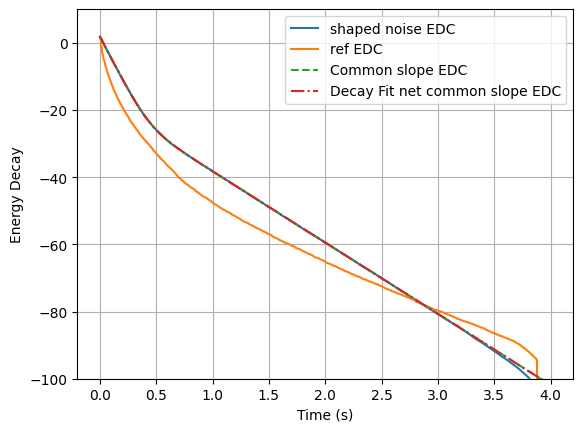

In [49]:
left_crop = int(fs*0.020)
right_crop = int(fs*0.005)
# sn_int = schroeder_backward_int(rirs.squeeze()[left_crop:-right_crop], normalize=False)
# ref_int = schroeder_backward_int(ref_rir[left_crop:(-right_crop), 0].squeeze(), normalize=False)
sn_int = schroeder_backward_int(rirs.squeeze(), normalize=False)
ref_int = schroeder_backward_int(ref_rir[:, 0].squeeze(), normalize=False)

# pad ref_init 
if len(ref_int) < len(sn_int):
    ref_int = np.pad(ref_int, (0, 1))
# TODO: apply filter bank and sum the bands to get the EDC

plt.plot(time_axis, 10*np.log10(sn_int), label='shaped noise EDC')
plt.plot(time_axis, 10*np.log10(ref_int), label='ref EDC')
plt.plot(time_axis, 10*np.log10(edc.sum(-1).squeeze()), '--', label='Common slope EDC')
plt.plot(time_axis, 10*np.log10(edc_decayfitnet), '-.', label='Decay Fit net common slope EDC')

plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.ylim(-100, 10)
plt.legend()
plt.grid(True)
plt.show()